In [2]:
%pip install matplotlib

     ---------------------------------------- 9.3/9.3 MB 112.6 kB/s eta 0:00:00
     ------------------------------------- 225.2/225.2 kB 36.2 kB/s eta 0:00:00
     ---------------------------------------- 2.5/2.5 MB 73.4 kB/s eta 0:00:00
     -------------------------------------- 70.7/70.7 kB 117.5 kB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd()

# If notebook starts inside Preprocessing/, move to project root
if not (PROJECT_ROOT / "Data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "Data" / "UCI HAR Dataset"

print("Project root:", PROJECT_ROOT)
print("Dataset path:", DATA_DIR)
print("Dataset exists:", DATA_DIR.exists())

Project root: f:\research\Deep-Learning-Assignment
Dataset path: f:\research\Deep-Learning-Assignment\Data\UCI HAR Dataset
Dataset exists: True


In [7]:
SIGNALS = [
    "body_acc_x",
    "body_acc_y",
    "body_acc_z",
    "body_gyro_x",
    "body_gyro_y",
    "body_gyro_z",
    "total_acc_x",
    "total_acc_y",
    "total_acc_z"
]

In [8]:
def load_signals(base_path, split):
    signal_data = []

    for signal in SIGNALS:
        file_path = (
            base_path
            / split
            / "Inertial Signals"
            / f"{signal}_{split}.txt"
        )

        signal_data.append(
            np.loadtxt(file_path)
        )

    # (9, samples, 128)
    #      ↓
    # (samples, 128, 9)
    return np.transpose(
        np.array(signal_data),
        (1, 2, 0)
    )

In [9]:
X_train_original = load_signals(DATA_DIR, "train")
X_test_original = load_signals(DATA_DIR, "test")

print("Train:", X_train_original.shape)
print("Test:", X_test_original.shape)

Train: (7352, 128, 9)
Test: (2947, 128, 9)


In [10]:
y_train_original = np.loadtxt(
    DATA_DIR / "train" / "y_train.txt",
    dtype=int
)

y_test_original = np.loadtxt(
    DATA_DIR / "test" / "y_test.txt",
    dtype=int
)

In [11]:
ACTIVITY_NAMES = [
    "Walking",
    "Walking Upstairs",
    "Walking Downstairs",
    "Sitting",
    "Standing",
    "Laying"
]

In [13]:
subject_train_original = np.loadtxt(
    DATA_DIR / "train" / "subject_train.txt",
    dtype=int
)

subject_test_original = np.loadtxt(
    DATA_DIR / "test" / "subject_test.txt",
    dtype=int
)

In [14]:
print("Training subjects:",
      np.unique(subject_train_original))

print("Testing subjects:",
      np.unique(subject_test_original))

Training subjects: [ 1  3  5  6  7  8 11 14 15 16 17 19 21 22 23 25 26 27 28 29 30]
Testing subjects: [ 2  4  9 10 12 13 18 20 24]


In [15]:
print(
    "Train NaNs:",
    np.isnan(X_train_original).sum()
)

print(
    "Test NaNs:",
    np.isnan(X_test_original).sum()
)

print(
    "Train infinite values:",
    np.isinf(X_train_original).sum()
)

print(
    "Test infinite values:",
    np.isinf(X_test_original).sum()
)

Train NaNs: 0
Test NaNs: 0
Train infinite values: 0
Test infinite values: 0


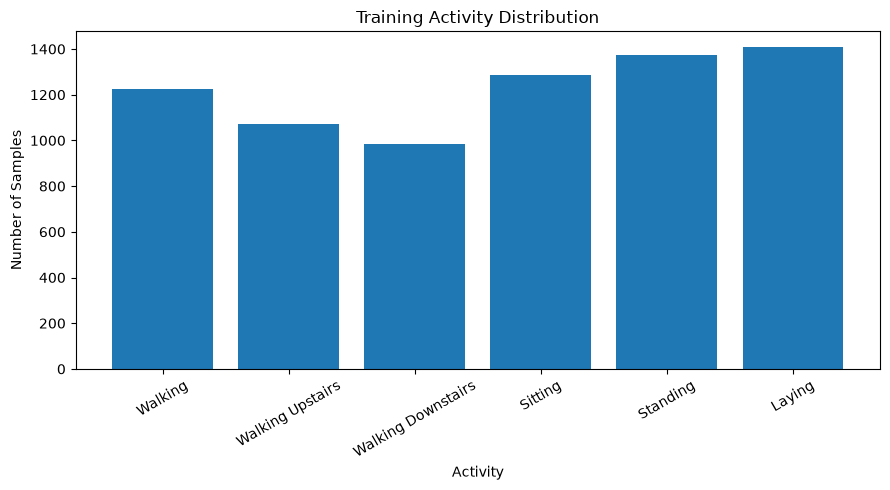

In [16]:
train_counts = pd.Series(
    y_train_original
).value_counts().sort_index()

plt.figure(figsize=(9, 5))

plt.bar(
    ACTIVITY_NAMES,
    train_counts.values
)

plt.title("Training Activity Distribution")
plt.xlabel("Activity")
plt.ylabel("Number of Samples")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

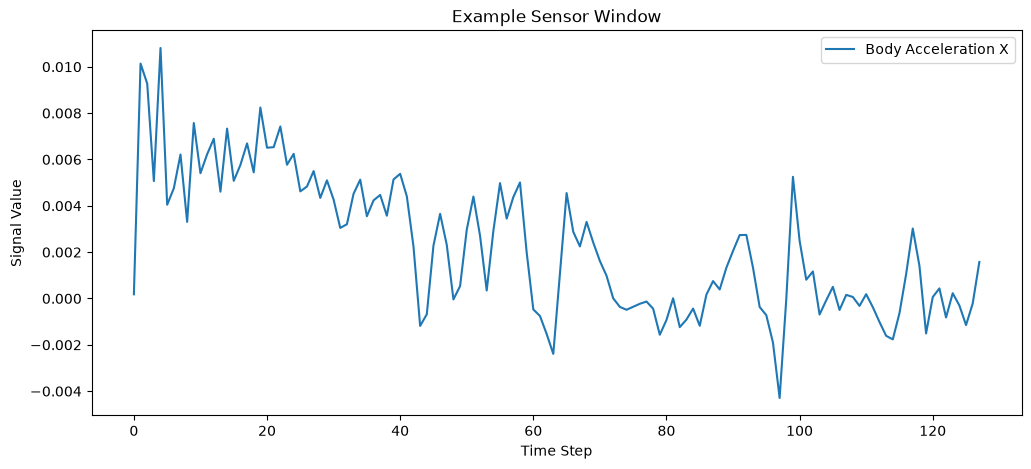

In [18]:
sample_index = 0

plt.figure(figsize=(12, 5))

plt.plot(
    X_train_original[sample_index, :, 0],
    label="Body Acceleration X"
)

plt.xlabel("Time Step")
plt.ylabel("Signal Value")
plt.title("Example Sensor Window")
plt.legend()
plt.show()